# Full environment flow

This notebook follows the main flow in `enviornment.py`:

1. Build the environment.
2. Create a randomized scene with an explicit seed using `new_scene(seed=...)`.
3. Load the RGB observation with `observation()`.
4. Build the matching target heatmap with `get_target_heatmap()`.
5. Increment the seed, create a second randomized scene, and repeat the same flow.

In [55]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Allow the notebook to run from either the repository root or CODE/Enviornment.
cwd = Path.cwd().resolve()
candidates = [
    cwd,
    cwd / "CODE" / "Enviornment",
    *[parent / "CODE" / "Enviornment" for parent in cwd.parents],
]
env_dir = next((path for path in candidates if (path / "enviornment.py").is_file()), None)
if env_dir is None:
    raise FileNotFoundError("Could not find CODE/Enviornment/enviornment.py")

if str(env_dir) not in sys.path:
    sys.path.insert(0, str(env_dir))

from enviornment import Enviornment
from enviornment_randomizer import Enviornment_Randomizer
from model_constants import Model_Constants
from randomization_constants import Randomization_Constants

print(f"Using environment code from: {env_dir}")

Using environment code from: /Users/aadibhatia/self-feeder-env/CODE/Enviornment


## Initialize the environment

In [56]:
# Each scene seed can reproduce that scene's randomization.
STARTING_SEED = 60
randomizer = Enviornment_Randomizer()
randomization_constants = Randomization_Constants()
model_constants = Model_Constants()
xml_file = env_dir / "xml_models" / "world.xml"

env = Enviornment(
    xml_file=str(xml_file),
    Enviornment_Randomizer=randomizer,
    Randomization_Constants=randomization_constants,
    checking_height=randomization_constants.in_scene_z_coordinate,
    Model_Constants=model_constants,
    starting_seed=STARTING_SEED,
)

print(f"Loaded: {xml_file}")
print(f"Starting seed: {env.seed}")

Loaded: /Users/aadibhatia/self-feeder-env/CODE/Enviornment/xml_models/world.xml
Starting seed: 60


## Display and validate one scene

The helper below keeps the same checks and visualization for both randomized scenes.

In [57]:
def show_scene(scene_name, observation, target_heatmap):
    camera = env.model.camera(randomization_constants.camera_name)
    width, height = map(int, env.model.cam_resolution[camera.id])

    expected_observation_shape = (height, width, 3)
    expected_heatmap_shape = (
        model_constants.output_y_dim,
        model_constants.output_x_dim,
    )

    assert observation.shape == expected_observation_shape, (
        f"Expected observation shape {expected_observation_shape}, got {observation.shape}"
    )
    assert target_heatmap.shape == expected_heatmap_shape, (
        f"Expected heatmap shape {expected_heatmap_shape}, got {target_heatmap.shape}"
    )
    assert np.isfinite(observation).all(), "Observation contains non-finite values"
    assert np.isfinite(target_heatmap).all(), "Heatmap contains non-finite values"

    print(f"{scene_name} observation shape: {observation.shape}")
    print(f"{scene_name} heatmap shape: {target_heatmap.shape}")
    print(
        f"{scene_name} heatmap range: "
        f"{target_heatmap.min():.4f} to {target_heatmap.max():.4f}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(observation)
    axes[0].set_title(f"{scene_name}: RGB observation")
    axes[0].axis("off")

    heatmap_image = axes[1].imshow(
        target_heatmap,
        cmap="hot",
        vmin=0,
        vmax=model_constants.max_reward,
        interpolation="nearest",
    )
    axes[1].set_title(f"{scene_name}: target heatmap")
    axes[1].set_xlabel("Heatmap x pixel")
    axes[1].set_ylabel("Heatmap y pixel")
    fig.colorbar(heatmap_image, ax=axes[1], label="Target reward")
    fig.tight_layout()
    plt.show()

## Scene 1: randomize, observe, and create the target heatmap

Scene 1 seed: 60
Scene 1 observation shape: (1080, 1920, 3)
Scene 1 heatmap shape: (144, 256)
Scene 1 heatmap range: 0.0000 to 0.9850


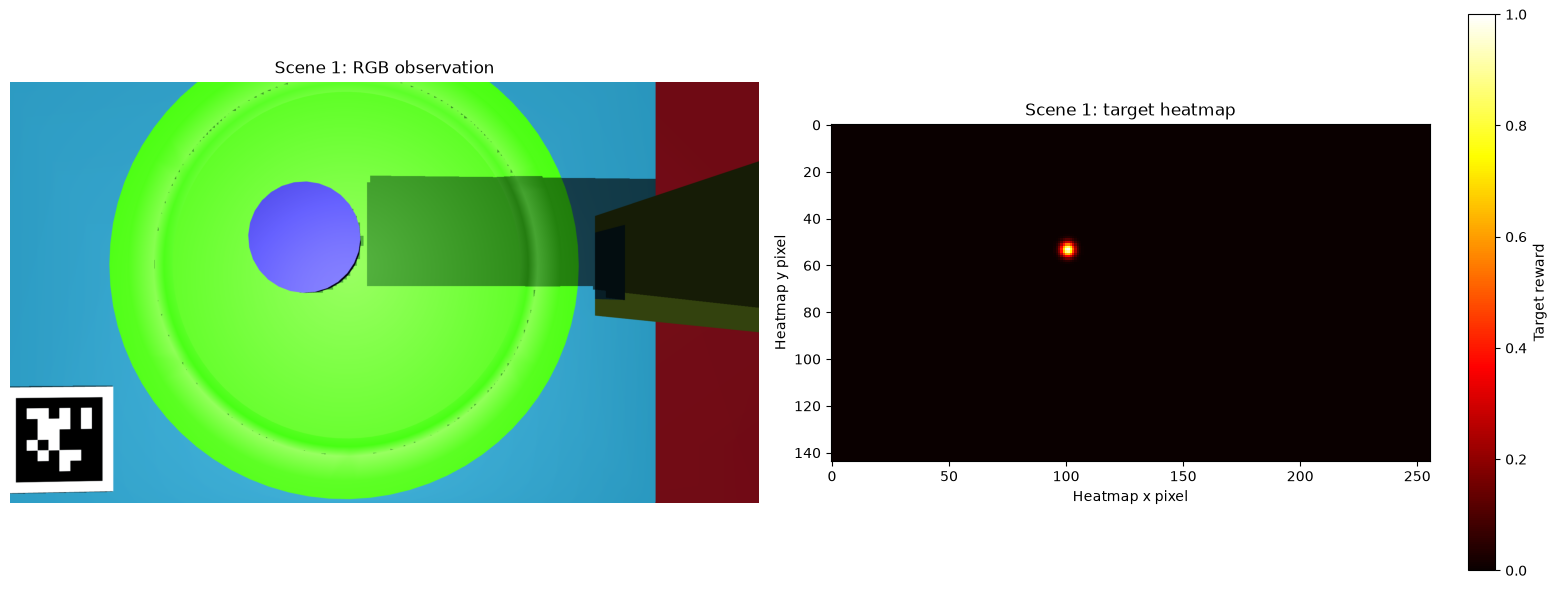

In [58]:
scene_1_seed = env.seed
scene_1_model, scene_1_data = env.new_scene(seed=scene_1_seed)
scene_1_observation = env.observation()
scene_1_target_heatmap = env.get_target_heatmap()

print(f"Scene 1 seed: {scene_1_seed}")
show_scene("Scene 1", scene_1_observation, scene_1_target_heatmap)

## Scene 2: make a new scene and repeat the full flow

Scene 2 seed: 61
Scene 2 observation shape: (1080, 1920, 3)
Scene 2 heatmap shape: (144, 256)
Scene 2 heatmap range: 0.0000 to 0.9536


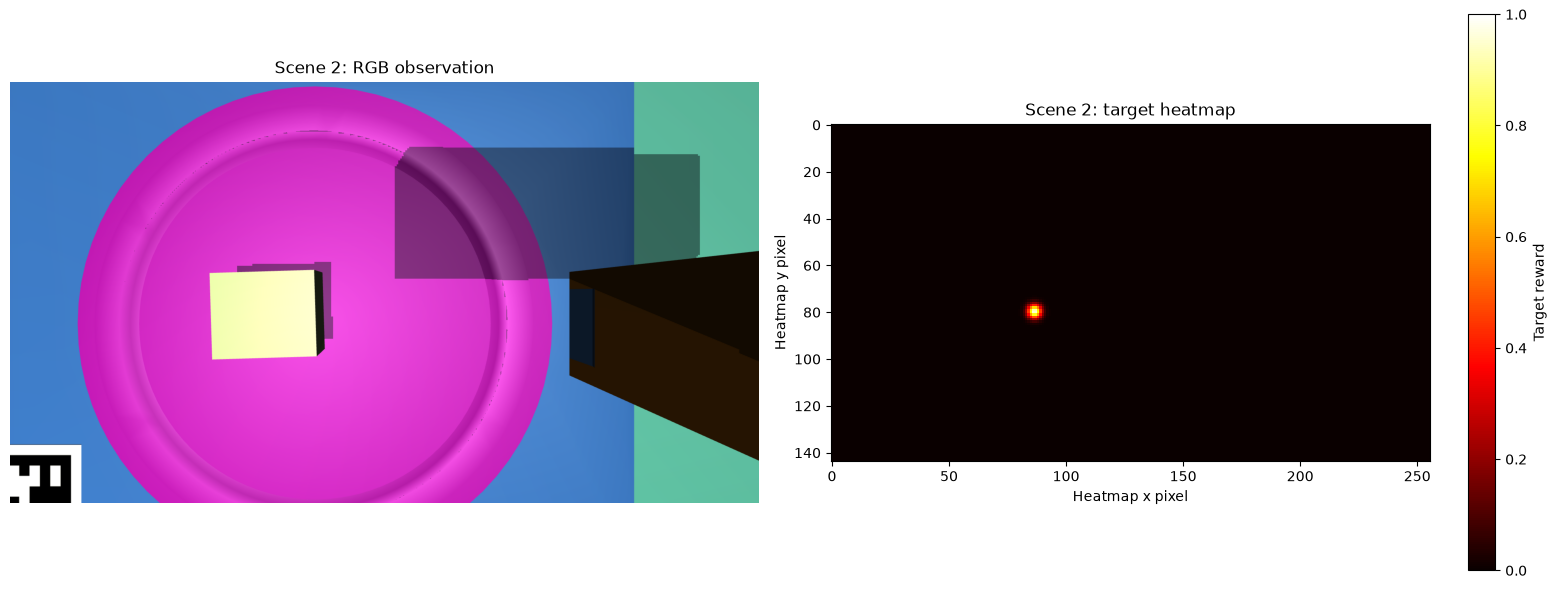

In [59]:
scene_2_seed = scene_1_seed + 1
scene_2_model, scene_2_data = env.new_scene(seed=scene_2_seed)
scene_2_observation = env.observation()
scene_2_target_heatmap = env.get_target_heatmap()

print(f"Scene 2 seed: {scene_2_seed}")
show_scene("Scene 2", scene_2_observation, scene_2_target_heatmap)

## Confirm that the randomized scene changed

In [60]:
observation_changed = not np.array_equal(scene_1_observation, scene_2_observation)
heatmap_changed = not np.array_equal(scene_1_target_heatmap, scene_2_target_heatmap)

print(f"RGB observation changed: {observation_changed}")
print(f"Target heatmap changed: {heatmap_changed}")

RGB observation changed: True
Target heatmap changed: True
